## <center> Prelims 2024
### <center> Mani Tyagi
#### <center> 200973108

In [53]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import gmres

The given minimization problem is 
\begin{align*}
    \min_{\mathbf{w} \in \mathbb{R}^L} \left\{ \sum_{i=1}^{N}  \left( y_i - \sum_{\ell=1}^{L}w_\ell \phi_\ell(x_i) \right)^2 \right\}
\end{align*}
In modified form it can be written as 
\begin{align*}
     \min_{\mathbf{w} \in \mathbb{R}^L} ||\mathbf{y} - X\mathbf{w}||^2
\end{align*}

### Part (a)

The matrix $X$ can be constructed using the given basis functions $\phi_j(x)$ with $(j = 1, 2, 3, 4, ....,L)$ and the data points $(x_i, y_i)$. Each row of $X$ corresponds to a data point $(x_i, y_i)$, and each column corresponds to a basis function $\phi_j(x)$. The element $X_{ij}$ represents the value of the $j$-th basis function evaluated at the $i$-th data point $x_i$.

Therefore, the matrix $X$ can be written as:

$$
X = 
\begin{bmatrix}
\phi_1(x_1) & \phi_2(x_1) & \cdots & \phi_L(x_1) \\
\phi_1(x_2) & \phi_2(x_2) & \cdots & \phi_L(x_2) \\
\vdots & \vdots & \ddots & \vdots \\
\phi_1(x_N) & \phi_2(x_N) & \cdots & \phi_L(x_N) \\
\end{bmatrix}
$$

Each row represents a data point, and each column represents a basis function evaluated at all data points. The given basis function is 
\begin{align*}
    \phi_i(x) = \exp(-1000(x-c_i)^2) \  \text{     where } i=1,.....,100
\end{align*}

### Part (b)

In [54]:
# function to define basis function phi
def basis_functions(x, c):
    return np.exp(-1000 * (x - c)**2)

In [55]:
# function to create matrix X 
def create_X(x, c_values):

    N = len(x)
    L = len(c_values)
    X = np.zeros((N, L))

    for i in range(L):
        X[:, i] = basis_functions(x, c_values[i])

    return X

# testing the function
x = np.linspace(0, 1, 4)
c = np.linspace(0, 1, 4)
X = create_X(x, c)
print("Matrix A:\n", X)

Matrix A:
 [[1.00000000e+000 5.55977948e-049 9.55499062e-194 0.00000000e+000]
 [5.55977948e-049 1.00000000e+000 5.55977948e-049 9.55499062e-194]
 [9.55499062e-194 5.55977948e-049 1.00000000e+000 5.55977948e-049]
 [0.00000000e+000 9.55499062e-194 5.55977948e-049 1.00000000e+000]]


In [1]:
def solve_least_squares(x, y, c_values, lambda_val):
    """
    --------------------------------------------------------------------------------------
    Function: Solve the regularized least squares problem.

    Parameters:
        x : The input values with shape (N,).
        y : The target values with shape (N,).
        c_values : The values of basis function centers with shape (L,).
        lambda_val : The regularization parameter.

    Returns:
        - error and weight norm.
    ---------------------------------------------------------------------------------------    
    """
    N = len(x)  # Number of samples
    L = len(c_values)  # Number of basis functions
    I = np.eye(L)  # Identity matrix of shape (L, L)

    # Create the matrix X
    X = np.zeros((N, L))
    X = create_X(x, c_values)

    # Solve the regularized least squares problem
    w = np.linalg.solve(X.T @ X + lambda_val * I, X.T @ y)

    # Evaluate error and coefficient norm
    error = np.linalg.norm(y - X @ w) ** 2
    weight_norm = np.linalg.norm(w) ** 2

    return error, weight_norm


In [57]:
# Testing the function
N = 10
x = np.linspace(0, 1, N)
y = np.sin(2 * np.pi * x) + 0.1*np.sin(20*np.pi*x)
# Define basis functions
c_values = np.linspace(0, 1, 100)
lambda_val = 0.01
error, weight_norm = solve_least_squares(x, y, c_values, lambda_val)
print("Error:", error)
print("Weight Norm:", weight_norm)

Error: 3.496512804482613e-05
Weight Norm: 1.376303252276021


### Part (c)

The given regularized optimization problem is
\begin{equation*}
     \min_{\mathbf{w} \in \mathbf{R}^L} (||\mathbf{y} - X\mathbf{w}||^2 + \lambda||w||^2)
\end{equation*}
The first term in this equation is the objective function from the ordinary least square(OLS) regression. The second term is a regularization term, not present in OLS, which penalizes large $w$ values. 

In [58]:
# Generate data points
N = 100
x = np.linspace(0, 1, N)
y = np.sin(2 * np.pi * x) + 0.1*np.sin(20*np.pi*x)

# Define basis functions
c_values = np.linspace(0, 1, 100)
X = create_X(x, c_values)

# Set lambda values to test
lambda_values = [0.0, 1e-8, 1e-6, 1e-4, 1e-2, 1, 100]

# Initialize lists to store results
results = []

# Loop over lambda values
for lambda_val in lambda_values:

    # Evaluate the model
    error, weight_norm = solve_least_squares(x, y, c_values, lambda_val)
    
    # Store results
    results.append([lambda_val, error, weight_norm])

# Printing results
print("-" * 55)
print("{:<15} {:<15} {:<25}".format("Lambda", "Error", "Norm of Coefficients"))
print("-" * 55)
for result in results:
    print("{:<15g} {:<15.6f} {:<25.6f}".format(result[0], result[1], result[2]))
print("-" * 55)


-------------------------------------------------------
Lambda          Error           Norm of Coefficients     
-------------------------------------------------------
0               0.000000        29106.743685             
1e-08           0.000000        40.597778                
1e-06           0.000004        6.777142                 
0.0001          0.000052        2.417206                 
0.01            0.000703        1.844352                 
1               0.080763        1.611000                 
100             29.642011       0.088426                 
-------------------------------------------------------


If the assumptions of ordinary least squares (OLS) regression are met, the solution $ w = \left( X^{\mathsf{T}} X \right)^{-1} X^{\mathsf{T}} y $ with $ \lambda = 0 $ is both an unbiased estimator and the minimum-variance linear unbiased estimator. Introducing the term $ \lambda I $ leads to a biased solution, but it also reduces variance. Hence, larger values of $ \lambda $ result in lower variance. Thus, adjusting $ \lambda $ manages the trade-off between bias and variance. This behaviour is obtained in the solution of the given problem as well. For small $\lambda$ norm of error is small. But for larger values of regularization parameter $\lambda$, the error norm increases. 

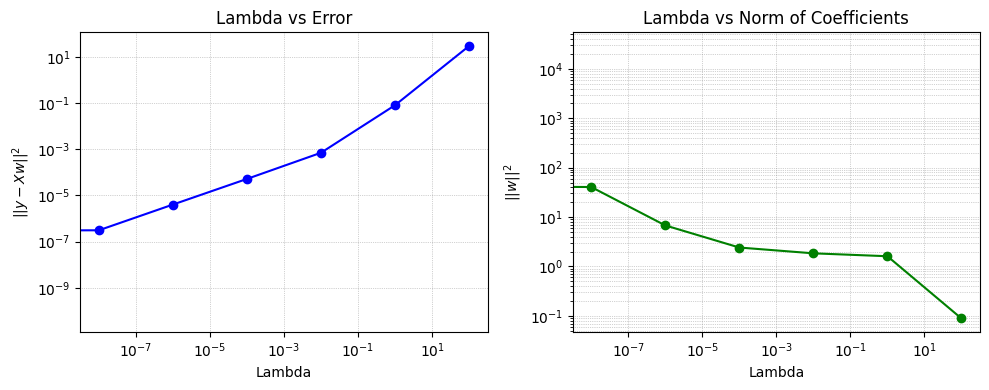

In [59]:
# Extracting lambda values, errors, and norm of coefficients for plotting
lambda_vals = [result[0] for result in results]
errors = [result[1] for result in results]
norms = [result[2] for result in results]

# Plotting lambda vs error
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.loglog(lambda_vals, errors, marker='o', linestyle='-', color='blue')
plt.xlabel('Lambda')
plt.ylabel('$||y - Xw||^2$')
plt.title('Lambda vs Error')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)

# Plotting lambda vs norm of coefficients
plt.subplot(1, 2, 2)
plt.loglog(lambda_vals, norms, marker='o', linestyle='-', color='green')
plt.xlabel('Lambda')
plt.ylabel('$||w||^2$')
plt.title('Lambda vs Norm of Coefficients')
plt.minorticks_on()
plt.grid(True, which='both', linestyle=':', linewidth='0.5', color='gray', alpha=0.7)

plt.tight_layout()
plt.show()

The results obtained can be summarized as follows:

- No Regularization ($\lambda = 0$):
    - Error: Very low (perfect fit)
    - Norm of Coefficients: Very high (potential over fitting)

- Small $\lambda$ Values (e.g., $1e-08$, $1e-06$):
    - Error: Close to zero
    - Norm of Coefficients: Significantly reduced

- Moderate $\lambda$ Values (e.g., $0.0001$, $0.01$):
    - Error: Slightly increases
    - Norm of Coefficients: Further decreased

- Large $\lambda$ Values (e.g., $1$, $100$):
    - Error: Increases significantly
    - Norm of Coefficients: Very low

- Conclusion:
  - The choice of $\lambda$ is critical to achieving a balance between fitting the data well and maintaining a simple model to prevent over-fitting.
  - Small to moderate values of $\lambda$ often provide a good trade-off, whereas very large values can lead to under-fitting.

### Part (d)

In [60]:
def solve_gmres(X, y, lambda_val, tol=1e-12, max_iter=100000):
    """----------------------------------------------------------------------------------------------------------
    Solve the regularized least squares problem using GMRES.

    Parameters:
    - X (array): Matrix of shape (N, L) where N is the number of data points and L is the number of basis functions.
    - y (array): Target values of shape (N,).
    - lambda_val (float): Regularization parameter.
    - tol (float, optional): Tolerance for the residual norm. Defaults is 1e-12.
    - max_iter (int, optional): Maximum number of iterations. Defaults is 10000.

    Returns:
    - w (array): Solution to the least squares problem.
    - iter_count (int): Number of GMRES iterations performed.
    - exit_code (int): Exit code indicating convergence or failure to converge.
    --------------------------------------------------------------------------------------------------------------"""
    L = X.shape[1]  # Number of basis functions
    I = np.eye(L)
    A = X.T @ X + lambda_val * I
    b = X.T @ y
    
    # callback function to count iterations
    def count_iter(x):
        count_iter.iter_count += 1
    
    count_iter.iter_count = 0  # Initialize iteration count
    
    w, info = gmres(A, b, tol=tol, maxiter=max_iter, callback=count_iter)
    
    return w, count_iter.iter_count

In [61]:
# Generate data points
N = 100
x = np.linspace(0, 1, N)
y = np.sin(2 * np.pi * x) + 0.1*np.sin(20*np.pi*x)

# Define basis functions
c_values = np.linspace(0, 1, 100)
X = create_X(x, c_values)

# Set lambda values to test
lambda_values = [0.0, 1e-8, 1e-6, 1e-4, 1e-2, 1, 100]

# Initialize list to store results
results = []

# Loop over lambda values
for lambda_val in lambda_values:
    
    # Evaluate the model
    error, weight_norm = solve_least_squares(x, y, c_values, lambda_val)
    
    # Solve the regularized least squares problem using GMRES
    w_gmres, exit_code = solve_gmres(X, y, lambda_val)
    
    # Calculate norm of w_gmres
    norm_w_gmres = np.linalg.norm(w_gmres)**2
    
    # Store results
    results.append([lambda_val, error, weight_norm, exit_code, norm_w_gmres])

print("-" * 90)
print("{:<15} {:<15} {:<25} {:<15} {:<25}".format("Lambda", "Error", "Norm of Coefficients", "Iterations", "Norm of w_gmres"))
print("-" * 90)
for result in results:
    print("{:<15g} {:<15.6f} {:<25.6f} {:<15} {:<25.6f}".format(result[0], result[1], result[2], result[3], result[4]))
print("-" * 90)

------------------------------------------------------------------------------------------
Lambda          Error           Norm of Coefficients      Iterations      Norm of w_gmres          
------------------------------------------------------------------------------------------
0               0.000000        29106.743685              100000          4.577915                 
1e-08           0.000000        40.597778                 100000          4.554038                 
1e-06           0.000004        6.777142                  100000          4.387873                 
0.0001          0.000052        2.417206                  80557           2.417206                 
0.01            0.000703        1.844352                  945             1.844352                 
1               0.080763        1.611000                  29              1.611000                 
100             29.642011       0.088426                  9               0.088426                 
------------------

$\textbf{Discussion:}$ For small values of regularization parameter $\lambda$, GMRES method fails to converge even for very large number of iterations. And as value of $\lambda$ is increased, the iteration count decreases quite rapidly, suggesting a good convergence. 

$\textbf{Explaination:}$ The Gmres method does not reaches convergence for small $\lambda$ values. This is because for small $\lambda$ values $X^TX + \lambda I$ is ill conditioned. And these unpreconditioned iterative methods struggle to converge in such cases \cite{saunders2019least}. The condition number for different values of $\lambda$ is shown in Table-\ref{cond} and explains the convergence failure for small $\lambda$.

In [62]:
# Initialize list to store lambda values and condition numbers
lambda_cond_values = []

# Loop over lambda values
for lambda_val in lambda_values:
    
    # Calculate condition number
    L = X.shape[1]
    I = np.eye(L)
    A = X.T @ X + lambda_val * I
    cond_number = np.linalg.cond(A)
    
    # Append lambda value and condition number to the list
    lambda_cond_values.append([lambda_val, cond_number])
    
# Print the table headers
print("-" * 40)
print("{:<15} {:<25}".format("Lambda", "Condition Number"))
print("-" * 40)

# Loop over lambda values
for lambda_val, cond_number in lambda_cond_values:
    print("{:<15g} {:<25.6f}".format(lambda_val, cond_number))
print("-" * 40)


----------------------------------------
Lambda          Condition Number         
----------------------------------------
0               10385676005557310.000000 
1e-08           3064975467.217900        
1e-06           30649764.951245          
0.0001          306498.640253            
0.01            3065.976403              
1               31.649764                
100             1.306498                 
----------------------------------------


As clear from the results the condition number for first three values of $\lambda$ is very large and hece GMRES fails to converge quickly.